<a href="https://colab.research.google.com/github/Ashish2343/R-MoE-Architecture-Comparisions/blob/main/Incremental_Adaptive_Hoeffding_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install river

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 25.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import pandas as pd
from river import tree, preprocessing, compose, metrics, stream, utils, datasets, drift
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.stats import linregress
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/AI Reasearch/CICIDS/Incremental01/final_data1.csv')

In [ ]:
data.shape

(435732, 78)

In [ ]:
label_encoder = LabelEncoder()
data["Label_encoded"] = label_encoder.fit_transform(data["Label"])

In [ ]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
sample = data.sample(n=1000, random_state=42)

In [ ]:
df_remaining = data.drop(sample.index)

In [ ]:
X_test = sample.drop(columns=["Label", "Label_encoded"])
y_test = sample["Label_encoded"]

In [ ]:
X = df_remaining.drop(columns=["Label", "Label_encoded"])
y = df_remaining["Label_encoded"]

In [ ]:
def get_holdout_accuracy(dataset_list):
    """Calculates accuracy on a static list without learning."""
    val_metric = metrics.Accuracy()
    for x_val, y_val in dataset_list:
        p_val = model1.predict_one(x_val)
        if p_val is not None:
            val_metric.update(y_val, p_val)
    return val_metric.get()

# **No Drift**

In [ ]:
dataset = stream.iter_pandas(X, y)

In [ ]:
val_set_group = list(stream.iter_pandas(X_test, y_test))

In [ ]:
# Model
model1 =  tree.HoeffdingAdaptiveTreeClassifier(
      grace_period=200,
      delta=1e-7,
      drift_detector=drift.ADWIN(delta=0.002),
      tau = 0.05,
      leaf_prediction="nba"
  )

In [ ]:
WINDOW_SIZE = 5000

acc_metric_1 = utils.Rolling(metrics.Accuracy(), window_size=WINDOW_SIZE)
kappa_metric_1 = utils.Rolling(metrics.CohenKappa(), window_size=WINDOW_SIZE)
rolling_macro_f1 = utils.Rolling(metrics.MacroF1(), window_size=WINDOW_SIZE)

max_acc_g0 = 0.0
max_acc_g1 = 0.0
forgetting_history = []

accuracy_values = []
kappa_values = []
rolling_macro_f1_values = []
timestamps_1 = []
steps = []

log_interval_1 = 1000

In [ ]:
log_interval_1 = 1000

for i, (x, y_true) in enumerate(dataset, start=1):

    y_pred = model1.predict_one(x)

    if y_pred is not None:
        acc_metric_1.update(y_true, y_pred)
        kappa_metric_1.update(y_true, y_pred)
        rolling_macro_f1.update(y_true, y_pred)

    model1.learn_one(x, y_true)

    # --- C. EVALUATE FORGETTING (Every 1000 steps) ---
    if i % log_interval_1 == 0:


      if len(val_set_group) > 0:
            current_acc = get_holdout_accuracy(val_set_group)
      else:
            current_acc = 0.0

      if current_acc > max_acc_g0: max_acc_g0 = current_acc

      f_max = max(0, max_acc_g0 - current_acc)


      forgetting_history.append(f_max)

      steps.append(i)
      accuracy_values.append(acc_metric_1.get())
      kappa_values.append(kappa_metric_1.get())
      rolling_macro_f1_values.append(rolling_macro_f1.get())

      if i % 50_000 == 0:
          print(f"Step {i} | Acc: {acc_metric_1.get():.3f} | Kappa: {kappa_metric_1.get():.3f}")

Step 50000 | Acc: 0.819 | Kappa: 0.738
Step 100000 | Acc: 0.880 | Kappa: 0.825
Step 150000 | Acc: 0.922 | Kappa: 0.889
Step 200000 | Acc: 0.925 | Kappa: 0.894
Step 250000 | Acc: 0.948 | Kappa: 0.926
Step 300000 | Acc: 0.961 | Kappa: 0.944
Step 350000 | Acc: 0.953 | Kappa: 0.932
Step 400000 | Acc: 0.960 | Kappa: 0.943


In [ ]:
accuracy_values = np.array(accuracy_values)
kappa_values = np.array(kappa_values)
rolling_macro_f1_values = np.array(rolling_macro_f1_values)
forgetting_history = np.array(forgetting_history)
steps = np.array(steps)


# A. Forgetting (Average over the whole experiment)
avg_forgetting = forgetting_history.mean()
final_forgetting = forgetting_history[-1] if len(forgetting_history) > 0 else 0.0

lowest_accuracy  = accuracy_values.min()
highest_accuracy = accuracy_values.max()
average_accuracy = accuracy_values.mean()

lowest_kappa  = kappa_values.min()
highest_kappa = kappa_values.max()
average_kappa = kappa_values.mean()

lowest_rolling_macro_f1  = rolling_macro_f1_values.min()
highest_rolling_macro_f1 = rolling_macro_f1_values.max()
average_rolling_macro_f1 = rolling_macro_f1_values.mean()

#AUC
auc_accuracy = simpson(accuracy_values, dx=1)
auc_kappa = simpson(kappa_values, dx=1)


# Variance (Stability)
accuracy_variance = np.var(accuracy_values)


In [ ]:
print("="*40)
print("NO-DRIFT BASELINE METRICS")
print("="*40)

print(f"Minimum Accuracy:      {lowest_accuracy:.4f}")
print(f"Maximum Accuracy:      {highest_accuracy:.4f}")
print(f"Average Accuracy:      {average_accuracy:.4f}")

print(f"Minimum Kappa:         {lowest_kappa:.4f}")
print(f"Maximum Kappa:         {highest_kappa:.4f}")
print(f"Average Kappa:         {average_kappa:.4f}")

print(f"Minimum Macro F1:      {lowest_rolling_macro_f1:.4f}")
print(f"Maximum Macro F1:      {highest_rolling_macro_f1:.4f}")
print(f"Average Macro F1:      {average_rolling_macro_f1:.4f}")

print(f"AUC (Accuracy):        {auc_accuracy:.2f}")
print(f"AUC (Kappa):           {auc_kappa:.2f}")
print(f"Average Forgetting: {avg_forgetting:.3f}")
print(f"Final Forgetting: {final_forgetting:.3f}")
print(f"Accuracy Variance:     {accuracy_variance:.6f}")

print("\nFinal Rolling Metrics")
print("Accuracy:", acc_metric_1.get())
print("Kappa:   ", kappa_metric_1.get())

print("="*40)

NO-DRIFT BASELINE METRICS
Minimum Accuracy:      0.4314
Maximum Accuracy:      0.9622
Average Accuracy:      0.8927
Minimum Kappa:         0.0000
Maximum Kappa:         0.9460
Average Kappa:         0.8352
Minimum Macro F1:      0.1005
Maximum Macro F1:      0.8876
Average Macro F1:      0.7381
AUC (Accuracy):        386.73
AUC (Kappa):           361.98
Average Forgetting: 0.004
Final Forgetting: 0.000
Accuracy Variance:     0.012364

Final Rolling Metrics
Accuracy: 0.961
Kappa:    0.9438442628044726


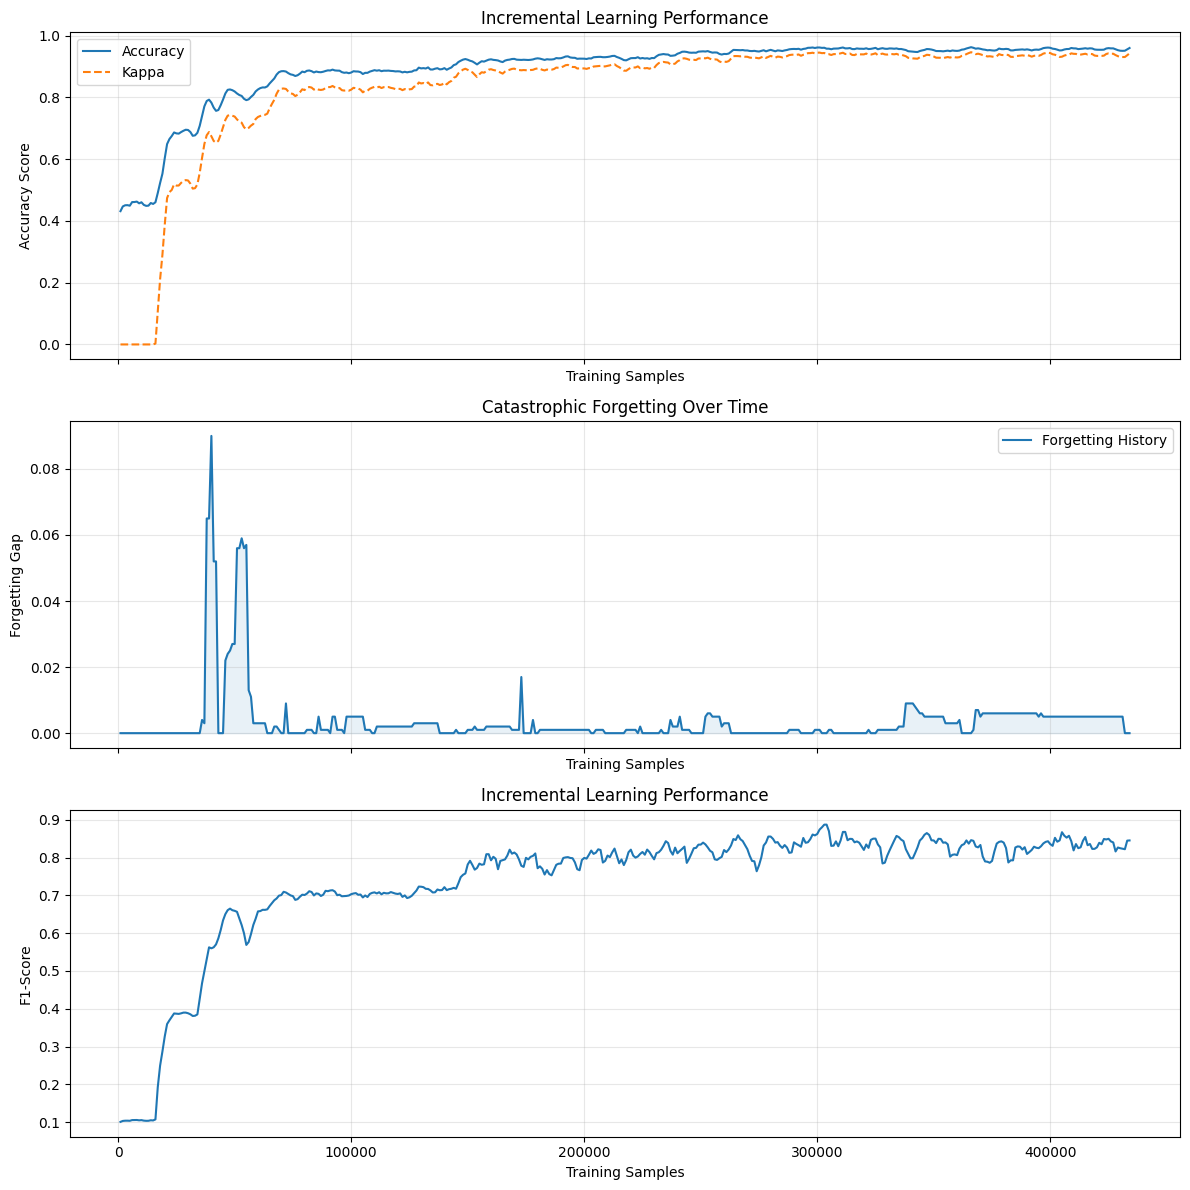

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: Accuracy & Kappa
ax1.plot(steps, accuracy_values, label='Accuracy', color='#1f77b4')
ax1.plot(steps, kappa_values, label='Kappa', color='#ff7f0e', linestyle='--')
ax1.set_ylabel("Accuracy Score")
ax1.set_xlabel("Training Samples")
ax1.set_title("Incremental Learning Performance")
ax1.grid(True, alpha=0.3)



ax1.legend()

# Plot 2: Forgetting
ax2.fill_between(steps, forgetting_history, color='#1f77b4', alpha=0.1)
ax2.plot(steps, forgetting_history, color='#1f77b4', label='Forgetting History')
ax2.set_ylabel("Forgetting Gap")
ax2.set_xlabel("Training Samples")
ax2.set_title("Catastrophic Forgetting Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1-Score
ax3.plot(steps, rolling_macro_f1_values, label='F1', color='#1f77b4')
ax3.set_ylabel("F1-Score")
ax3.set_xlabel("Training Samples")
ax3.set_title("Incremental Learning Performance")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Sudden Drift**

In [ ]:
dataset = stream.iter_pandas(X, y)
val_set_group = list(stream.iter_pandas(X_test, y_test))

In [ ]:
model1 = preprocessing.StandardScaler() | tree.HoeffdingAdaptiveTreeClassifier(
      grace_period=200,
      delta=1e-7,
      drift_detector=drift.ADWIN(delta=0.002),
      tau = 0.05,
      leaf_prediction="nba"
  )

In [ ]:
Drift_Map = {

    2: ([3], [1.0]),
    3: ([2], [1.0]),

    1: ([1, 0], [0.8, 0.2]),

    0: ([0, 1], [0.8, 0.2]),

    # --- 4. STABILITY (Control Group) ---
    4: ([4], [1.0]),
    5: ([5], [1.0])
}

In [ ]:
WINDOW_SIZE = 5000

acc_metric_1 = utils.Rolling(metrics.Accuracy(), window_size=WINDOW_SIZE)
kappa_metric_1 = utils.Rolling(metrics.CohenKappa(), window_size=WINDOW_SIZE)
rolling_macro_f1 = utils.Rolling(metrics.MacroF1(), window_size=5000)

max_acc_g0 = 0.0
max_acc_g1 = 0.0
forgetting_history = []

accuracy_values = []
kappa_values = []
rolling_macro_f1_values = []
timestamps_1 = []
steps = []

log_interval_1 = 1000

DRIFT_POINT = 200000

In [ ]:
for i, (x, y_true) in enumerate(dataset, start=1):


  if (i>=DRIFT_POINT):
    if y_true in Drift_Map:
        candidates, weights = Drift_Map[y_true]

        new_label = random.choices(candidates, weights, k=1)[0]
        y_true = new_label


  y_pred = model1.predict_one(x)

    # 2. Update Metrics
  if y_pred is not None:
      acc_metric_1.update(y_true, y_pred)
      kappa_metric_1.update(y_true, y_pred)
      rolling_macro_f1.update(y_true, y_pred)

  model1.learn_one(x, y_true)

  if i % log_interval_1 == 0:

    acc_old_g0 = get_holdout_accuracy(val_set_group)



    if i < DRIFT_POINT:
      max_acc_g0 = max(max_acc_g0, acc_old_g0)

    f_g0 = max(0, max_acc_g0 - acc_old_g0)

    forgetting_history.append(f_g0)


    steps.append(i)
    accuracy_values.append(acc_metric_1.get())
    kappa_values.append(kappa_metric_1.get())
    rolling_macro_f1_values.append(rolling_macro_f1.get())


  if i % 50_000 == 0:
    print(f"Step {i} | Acc: {acc_metric_1.get():.3f} | Kappa: {kappa_metric_1.get():.3f}")


Step 50000 | Acc: 0.842 | Kappa: 0.774
Step 100000 | Acc: 0.875 | Kappa: 0.827
Step 150000 | Acc: 0.919 | Kappa: 0.888
Step 200000 | Acc: 0.926 | Kappa: 0.896
Step 250000 | Acc: 0.779 | Kappa: 0.702
Step 300000 | Acc: 0.779 | Kappa: 0.707
Step 350000 | Acc: 0.800 | Kappa: 0.731
Step 400000 | Acc: 0.811 | Kappa: 0.746


In [ ]:
#  Define the Robust Slope Function

def get_tangent_recovery_slope(steps, acc_values, drift_point, window_steps=5000):

    steps = np.array(steps)
    acc_values = np.array(acc_values)


    mask_post_drift = steps > drift_point
    steps_post = steps[mask_post_drift]
    acc_post = acc_values[mask_post_drift]

    if len(steps_post) < 2: return None


    min_idx_local = np.argmin(acc_post)
    valley_acc = acc_post[min_idx_local]
    valley_step = steps_post[min_idx_local]


    start_measure = valley_step
    end_measure = valley_step + window_steps

    mask_window = (steps_post >= start_measure) & (steps_post <= end_measure)
    x_reg = steps_post[mask_window]
    y_reg = acc_post[mask_window]

    if len(x_reg) < 2: return None


    slope, intercept, _, _, _ = linregress(x_reg, y_reg)

    return {
        "slope_per_1k": slope * 1000,
        "valley_step": valley_step,
        "valley_acc": valley_acc,
        "plot_x": x_reg,
        "plot_y": slope * x_reg + intercept
    }

In [ ]:
accuracy_values = np.array(accuracy_values)
kappa_values = np.array(kappa_values)
rolling_macro_f1_values = np.array(rolling_macro_f1_values)
forgetting_history = np.array(forgetting_history)
steps = np.array(steps)


# A. Forgetting (Average over the whole experiment)
avg_forgetting = forgetting_history.mean()
final_forgetting = forgetting_history[-1] if len(forgetting_history) > 0 else 0.0

lowest_accuracy  = accuracy_values.min()
highest_accuracy = accuracy_values.max()
average_accuracy = accuracy_values.mean()

lowest_kappa  = kappa_values.min()
highest_kappa = kappa_values.max()
average_kappa = kappa_values.mean()

lowest_rolling_macro_f1  = rolling_macro_f1_values.min()
highest_rolling_macro_f1 = rolling_macro_f1_values.max()
average_rolling_macro_f1 = rolling_macro_f1_values.mean()


#AUC
auc_accuracy = simpson(accuracy_values, dx=1)
auc_kappa = simpson(kappa_values, dx=1)

auc_forgetting = simpson(forgetting_history, dx=1)


# Variance (Stability)
accuracy_variance = np.var(accuracy_values)


# Recovery Slop
slope_results = get_tangent_recovery_slope(steps, accuracy_values, DRIFT_POINT, window_steps=10000)


In [ ]:
print("="*40)
print("SUDDEN DRIFT BASELINE METRICS")
print("="*40)

print(f"Minimum Accuracy of Architecture:      {lowest_accuracy:.4f}")
print(f"Maximum Accuracy of Architecture:      {highest_accuracy:.4f}")
print(f"Average Accuracy of Architecture:      {average_accuracy:.4f}")

print(f"Minimum Kappa of Architecture:         {lowest_kappa:.4f}")
print(f"Maximum Kappa of Architecture:         {highest_kappa:.4f}")
print(f"Average Kappa of Architecture:         {average_kappa:.4f}")

print(f"Minimum Macro F1 of Architecture:      {lowest_rolling_macro_f1:.4f}")
print(f"Maximum Macro F1 of Architecture:      {highest_rolling_macro_f1:.4f}")
print(f"Average Macro F1 of Architecture:      {average_rolling_macro_f1:.4f}")

print(f"AUC (Accuracy):        {auc_accuracy:.2f}")
print(f"AUC (Kappa):           {auc_kappa:.2f}")
print(f"AUC (Forgetting):      {auc_forgetting:.2f}")
print(f"Average Forgetting: {avg_forgetting:.3f}")
print(f"Final Forgetting: {final_forgetting:.3f}")
print(f"Accuracy Variance:     {accuracy_variance:.6f}")
print(f"Initial Recovery Speed: {slope_results['slope_per_1k']:.4f} accuracy points per 1k steps")

print("\nFinal Rolling Metrics")
print("Accuracy:", acc_metric_1.get())
print("Kappa:   ", kappa_metric_1.get())

print("="*40)

SUDDEN DRIFT BASELINE METRICS
Minimum Accuracy of Architecture:      0.3484
Maximum Accuracy of Architecture:      0.9272
Average Accuracy of Architecture:      0.8169
Minimum Kappa of Architecture:         0.2595
Maximum Kappa of Architecture:         0.8978
Average Kappa of Architecture:         0.7534
Minimum Macro F1 of Architecture:      0.3282
Maximum Macro F1 of Architecture:      0.8430
Average Macro F1 of Architecture:      0.6812
AUC (Accuracy):        353.81
AUC (Kappa):           326.35
AUC (Forgetting):      54.15
Average Forgetting: 0.125
Final Forgetting: 0.195
Accuracy Variance:     0.007727
Initial Recovery Speed: 0.0015 accuracy points per 1k steps

Final Rolling Metrics
Accuracy: 0.8
Kappa:    0.7309738375823416


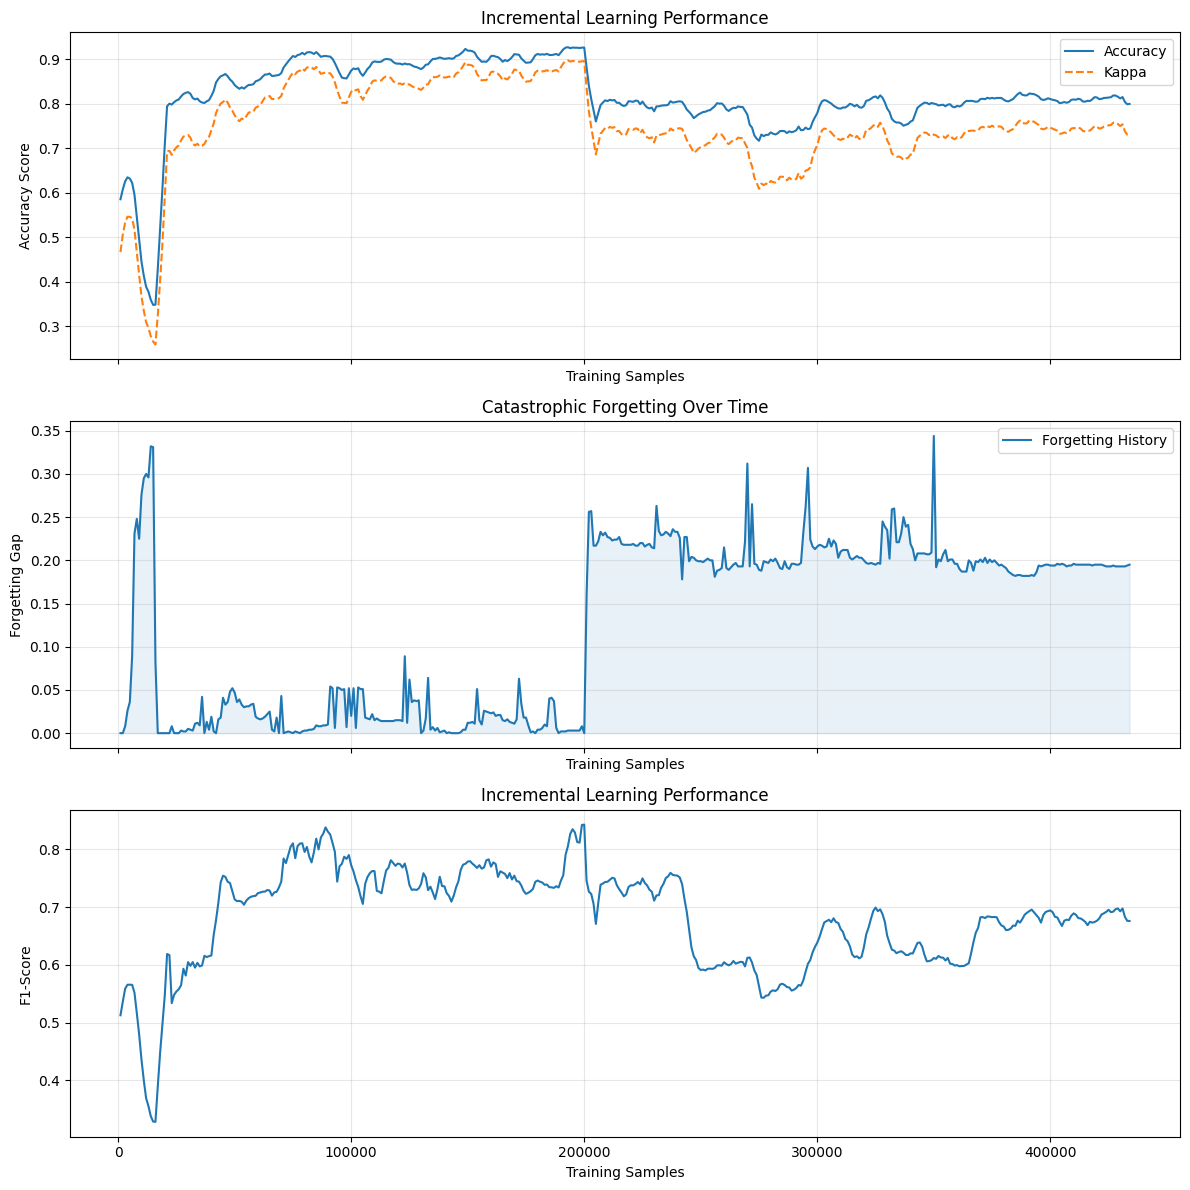

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: Accuracy & Kappa
ax1.plot(steps, accuracy_values, label='Accuracy', color='#1f77b4')
ax1.plot(steps, kappa_values, label='Kappa', color='#ff7f0e', linestyle='--')
ax1.set_ylabel("Accuracy Score")
ax1.set_xlabel("Training Samples")
ax1.set_title("Incremental Learning Performance")
ax1.grid(True, alpha=0.3)


ax1.legend()

# Plot 2: Forgetting
ax2.fill_between(steps, forgetting_history, color='#1f77b4', alpha=0.1)
ax2.plot(steps, forgetting_history, color='#1f77b4', label='Forgetting History')
ax2.set_ylabel("Forgetting Gap")
ax2.set_xlabel("Training Samples")
ax2.set_title("Catastrophic Forgetting Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1-Score
ax3.plot(steps, rolling_macro_f1_values, label='F1', color='#1f77b4')
ax3.set_ylabel("F1-Score")
ax3.set_xlabel("Training Samples")
ax3.set_title("Incremental Learning Performance")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()